# **Genetic Algorithm: Portfolio Selection & Optimization**
---

This notebook implements a **Genetic Algorithm (GA)** to solve the portfolio selection and
weight optimization problem. Unlike K-Means clustering (which groups similar assets) the GA
simultaneously **selects which stocks to include** and **optimizes their weights**.

**Approach:**
- The GA evolves a population of candidate portfolios over multiple generations.
- Each individual encodes both a **subset of stocks** and their **allocation weights**.
- The fitness function evaluates portfolios based on the insurer's mandate:
  low volatility, controlled beta, and reasonable returns.

**Train/Test Split:**
- **Training (2022–2023):** The GA optimizes portfolios using only this data.
- **Testing (2024):** Out-of-sample backtest to validate the strategy.

## **1. Imports & Data Loading**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import random
import warnings
from copy import deepcopy

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
np.random.seed(42)
random.seed(42)

stock_data = pd.read_csv('stock_data.csv', index_col=0, parse_dates=True)
raw_dataset = pd.read_csv('raw_dataset.csv', index_col=0)
fundamentals = pd.read_csv('fundamentals.csv', index_col=0)

print(f"Stock data: {stock_data.shape}")
print(f"Period: {stock_data.index[0].date()} → {stock_data.index[-1].date()}")

Stock data: (753, 1469)
Period: 2022-01-03 → 2024-12-31


### **1.2 Compute Daily Returns & Train/Test Split**

We split the data into:
- **Training period (2022-01-01 to 2023-12-31):** Used by the GA to evolve portfolios.
- **Test period (2024-01-01 to 2024-12-31):** Out-of-sample validation.

In [2]:
daily_returns = stock_data.pct_change().dropna()

cutoff_date = '2024-01-01'

train_returns = daily_returns.loc[daily_returns.index < cutoff_date]
test_returns = daily_returns.loc[daily_returns.index >= cutoff_date]

print(f"\nTraining: {train_returns.index[0].date()} → {train_returns.index[-1].date()} ({len(train_returns)} days)")
print(f"Testing:  {test_returns.index[0].date()} → {test_returns.index[-1].date()} ({len(test_returns)} days)")


Training: 2022-03-30 → 2023-12-29 (441 days)
Testing:  2024-01-02 → 2024-12-31 (252 days)


### **1.3 Define Valid Tickers**

We restrict the universe to tickers that:
1. Have complete price data (no NaN in training period).
2. Appear in the `raw_dataset.csv` (i.e., have all 9 features computed).

In [3]:
valid_tickers = [t for t in daily_returns.columns
                 if train_returns[t].isna().sum() == 0
                 and test_returns[t].isna().sum() == 0
                 and t in raw_dataset.index
                 and t in fundamentals.index]

stock_betas = {}
for t in valid_tickers:
    b = fundamentals.loc[t, 'beta'] if t in fundamentals.index else 1.0
    stock_betas[t] = b if pd.notna(b) else 1.0

stock_train_vol = {}
for t in valid_tickers:
    stock_train_vol[t] = train_returns[t].std() * np.sqrt(252)

stock_pe = {}
stock_roe = {}
stock_mcap = {}

for t in valid_tickers:
    pe = fundamentals.loc[t, 'pe_ratio'] if t in fundamentals.index else np.nan
    roe = fundamentals.loc[t, 'roe'] if t in fundamentals.index else np.nan
    mcap = fundamentals.loc[t, 'market_cap'] if t in fundamentals.index else np.nan
    stock_pe[t] = pe if pd.notna(pe) else np.nan
    stock_roe[t] = roe if pd.notna(roe) else np.nan
    stock_mcap[t] = mcap if pd.notna(mcap) else np.nan

# Precompute median P/E and ROE for normalization
valid_pe = [v for v in stock_pe.values() if pd.notna(v) and v > 0]
valid_roe = [v for v in stock_roe.values() if pd.notna(v)]
valid_mcap = [v for v in stock_mcap.values() if pd.notna(v) and v > 0]

MEDIAN_PE = np.median(valid_pe)
MEDIAN_ROE = np.median(valid_roe)
MEDIAN_MCAP = np.median(valid_mcap)

print(f"Valid tickers: {len(valid_tickers)}")
print(f"\nFundamentals stats:")
print(f"  Median P/E:        {MEDIAN_PE:.1f}")
print(f"  Median ROE:        {MEDIAN_ROE:.4f}")
print(f"  Median Market Cap: ${MEDIAN_MCAP/1e9:.1f}B")

Valid tickers: 1212

Fundamentals stats:
  Median P/E:        23.8
  Median ROE:        0.1300
  Median Market Cap: $8.4B


## **2. Genetic Algorithm Design**
---

### **2.1 GA Parameters**

The parameters are calibrated for an insurance mandate:
- **Portfolio size:** 50 stocks for broad diversification.
- **Target beta:** 0.6 (defensive positioning).
- **Weighting:** Inverse-Volatility Weighting — lower volatility stocks receive higher weights: $w_i = \frac{1/\sigma_i}{\sum_j 1/\sigma_j}$, clipped to $[0.5\%, 6\%]$ to prevent concentration.
- **Early stopping:** Convergence criterion stops evolution when the fitness stagnates for 20 consecutive generations (max 300 generations).

In [4]:
PORTFOLIO_SIZE = 50
POPULATION_SIZE = 150
GENERATIONS = 300
STAGNATION_LIMIT = 20
RISK_FREE_RATE = 0.04

# Fitness weights 
W_RETURN = 0.25
W_VOLATILITY = 0.25
W_BETA_TARGET = 0.10
W_DRAWDOWN = 0.10
W_FUNDAMENTALS = 0.30      

TARGET_BETA = 0.6
ELITE_COUNT = 20
MUTATION_RATE = 0.4
MAX_SWAPS = 5

# Weight bounds
MIN_WEIGHT = 0.005
MAX_WEIGHT = 0.06
WEIGHT_MUTATION_STD = 0.008

print("GA PARAMETERS")
print(f"Portfolio:      {PORTFOLIO_SIZE} stocks")
print(f"Weights:        Inverse-Vol based [{MIN_WEIGHT:.1%} - {MAX_WEIGHT:.1%}]")
print(f"Fitness split:  Ret({W_RETURN}) Vol({W_VOLATILITY}) Beta({W_BETA_TARGET}) DD({W_DRAWDOWN}) Fund({W_FUNDAMENTALS})")
print(f"Target Beta:    {TARGET_BETA}")
print(f"Early stop:     {STAGNATION_LIMIT} gen stagnation or {GENERATIONS} gen max")

GA PARAMETERS
Portfolio:      50 stocks
Weights:        Inverse-Vol based [0.5% - 6.0%]
Fitness split:  Ret(0.25) Vol(0.25) Beta(0.1) DD(0.1) Fund(0.3)
Target Beta:    0.6
Early stop:     20 gen stagnation or 300 gen max


### **2.2 Individual Representation**

Each individual (chromosome) is a tuple:
- `tickers`: list of selected stock tickers (length = PORTFOLIO_SIZE)
- `weights`: numpy array of portfolio weights (sum = 1, all >= 0)

In [5]:
def compute_inv_vol_weights(tickers):
    """Inverse Vol Weighting : stocks moins volatils → plus de poids."""
    vols = np.array([stock_train_vol.get(t, 0.3) for t in tickers])
    inv_vol = 1.0 / np.maximum(vols, 0.01)
    weights = inv_vol / inv_vol.sum()
    weights = np.clip(weights, MIN_WEIGHT, MAX_WEIGHT)
    weights = weights / weights.sum()
    return weights


def create_individual():
    """Crée un individu : tickers + poids inverse-vol avec léger bruit."""
    tickers = random.sample(valid_tickers, PORTFOLIO_SIZE)
    weights = compute_inv_vol_weights(tickers)
    noise = np.random.normal(0, 0.003, PORTFOLIO_SIZE)
    weights = np.clip(weights + noise, MIN_WEIGHT, MAX_WEIGHT)
    weights = weights / weights.sum()
    return {'tickers': tickers, 'weights': weights}

### **2.3 Fitness Function**

The fitness function evaluates each portfolio on the **training data only** (no data leakage).
It combines **market-based metrics** and **fundamental analysis**, aligned with the insurer's defensive mandate:

$$\text{Score} = \underbrace{w_R \cdot R_p \cdot 100}_{\text{Return}} - \underbrace{w_\sigma \cdot \sigma_p \cdot 200}_{\text{Volatility}} - \underbrace{w_\beta \cdot |\beta_p - 0.6| \cdot 100}_{\beta \text{ Deviation}} - \underbrace{w_{DD} \cdot |DD_{\max}| \cdot 100}_{\text{Drawdown}} + \underbrace{w_F \cdot S_F \cdot 100}_{\text{Fundamentals}}$$

**Weights:** $w_R = 0.25$, $w_\sigma = 0.25$, $w_\beta = 0.10$, $w_{DD} = 0.10$, $w_F = 0.30$

The **Fundamental Score** $S_F$ (30% of the fitness) integrates three dimensions from `fundamentals.csv`:

| Component | What it rewards | Formula |
|---|---|---|
| **P/E Score** | Reasonable valuations (not overpaying) | $\max(0,\; 1 - \text{PE}_p / (2 \cdot \text{PE}_{\text{median}}))$ |
| **ROE Score** | Profitable companies | $\min(1,\; \text{ROE}_p / (2 \cdot \text{ROE}_{\text{median}}))$ |
| **Liquidity Score** | Large-cap stocks (insurer liquidity needs) | Weighted % of stocks with Market Cap > median |


In [6]:
def compute_fundamental_score(tickers, weights):
    """
    Score fondamental du portefeuille.
    """
    # Weighted P/E
    pe_values = []
    pe_weights = []
    for i, t in enumerate(tickers):
        pe = stock_pe.get(t, np.nan)
        if pd.notna(pe) and pe > 0:
            pe_values.append(pe)
            pe_weights.append(weights[i])
    
    if pe_values:
        w_arr = np.array(pe_weights)
        w_arr = w_arr / w_arr.sum()
        portfolio_pe = np.average(pe_values, weights=w_arr)
        # Score: lower P/E = better (cheaper stocks)
        pe_score = max(0, 1 - portfolio_pe / (2 * MEDIAN_PE))
    else:
        pe_score = 0
    
    # Weighted ROE
    roe_values = []
    roe_weights = []
    for i, t in enumerate(tickers):
        roe = stock_roe.get(t, np.nan)
        if pd.notna(roe):
            roe_values.append(roe)
            roe_weights.append(weights[i])
    
    if roe_values:
        w_arr = np.array(roe_weights)
        w_arr = w_arr / w_arr.sum()
        portfolio_roe = np.average(roe_values, weights=w_arr)
        roe_score = min(1, max(0, portfolio_roe / (2 * MEDIAN_ROE)))
    else:
        roe_score = 0
    
    # Liquidity (Market Cap)
    large_cap_weight = 0
    for i, t in enumerate(tickers):
        mcap = stock_mcap.get(t, np.nan)
        if pd.notna(mcap) and mcap > MEDIAN_MCAP:
            large_cap_weight += weights[i]
    
    liquidity_score = min(1, large_cap_weight)
    
    # Combined fundamental score
    # Equal weight between the 3 sub-components
    fundamental_score = (pe_score + roe_score + liquidity_score) / 3
    
    return {
        'fundamental_score': fundamental_score,
        'pe_score': pe_score,
        'roe_score': roe_score,
        'liquidity_score': liquidity_score,
        'portfolio_pe': portfolio_pe if pe_values else np.nan,
        'portfolio_roe': portfolio_roe if roe_values else np.nan,
        'large_cap_pct': large_cap_weight * 100
    }


def evaluate_portfolio(individual):
    tickers = individual['tickers']
    weights = individual['weights']

    # Market metrics (on train data)
    portfolio_daily_ret = (train_returns[tickers] * weights).sum(axis=1)
    ann_ret = portfolio_daily_ret.mean() * 252
    ann_vol = portfolio_daily_ret.std() * np.sqrt(252)
    avg_beta = sum(weights[i] * stock_betas[tickers[i]] for i in range(len(tickers)))

    cum = (1 + portfolio_daily_ret).cumprod()
    peak = cum.cummax()
    max_dd = ((cum - peak) / peak).min()
    sharpe = (ann_ret - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else -10

    # Fundamental metrics
    fund = compute_fundamental_score(tickers, weights)

    # Score
    beta_penalty = abs(avg_beta - TARGET_BETA)

    score = (
        (W_RETURN * ann_ret * 100)
        - (W_VOLATILITY * 100 * ann_vol * 2)
        - (W_BETA_TARGET * 100 * beta_penalty)
        - (W_DRAWDOWN * 100 * abs(max_dd))
        + (W_FUNDAMENTALS * 100 * fund['fundamental_score'])  
    )

    if ann_ret < 0:
        score -= 50
    if max_dd > -0.10:
        score += 5
    elif max_dd > -0.15:
        score += 2
    if sharpe > 0.5:
        score += 3

    return {
        'score': score,
        'ann_return': ann_ret,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'beta': avg_beta,
        'max_drawdown': max_dd,
        'max_weight': weights.max(),
        'min_weight': weights.min(),
        'fund_score': fund['fundamental_score'],
        'pe_score': fund['pe_score'],
        'roe_score': fund['roe_score'],
        'liq_score': fund['liquidity_score'],
        'portfolio_pe': fund['portfolio_pe'],
        'portfolio_roe': fund['portfolio_roe'],
        'large_cap_pct': fund['large_cap_pct']
    }

### **2.4 Genetic Operators**

In [7]:
def mutate(individual):
    """Mutation : swap de tickers + légère perturbation des poids."""
    ind = deepcopy(individual)

    if random.random() < MUTATION_RATE:
        nb_swaps = random.randint(1, MAX_SWAPS)
        for _ in range(nb_swaps):
            idx = random.randint(0, PORTFOLIO_SIZE - 1)
            new_t = random.choice(valid_tickers)
            attempts = 0
            while new_t in ind['tickers'] and attempts < 100:
                new_t = random.choice(valid_tickers)
                attempts += 1
            if new_t not in ind['tickers']:
                ind['tickers'][idx] = new_t
                new_vol = stock_train_vol.get(new_t, 0.3)
                ind['weights'][idx] = 1.0 / max(new_vol, 0.01)

        ind['weights'] = np.clip(ind['weights'], MIN_WEIGHT, None)
        ind['weights'] = ind['weights'] / ind['weights'].sum()
        ind['weights'] = np.clip(ind['weights'], MIN_WEIGHT, MAX_WEIGHT)
        ind['weights'] = ind['weights'] / ind['weights'].sum()

    if random.random() < 0.3:
        noise = np.random.normal(0, WEIGHT_MUTATION_STD, PORTFOLIO_SIZE)
        ind['weights'] = np.clip(ind['weights'] + noise, MIN_WEIGHT, MAX_WEIGHT)
        ind['weights'] = ind['weights'] / ind['weights'].sum()

    return ind


def crossover(parent1, parent2):
    """Crossover single-point avec transfert de poids."""
    cut = random.randint(10, PORTFOLIO_SIZE - 10)

    child_tickers = list(parent1['tickers'][:cut])
    child_weights = list(parent1['weights'][:cut])

    for i, t in enumerate(parent2['tickers']):
        if t not in child_tickers and len(child_tickers) < PORTFOLIO_SIZE:
            child_tickers.append(t)
            if t in parent1['tickers']:
                idx_p1 = parent1['tickers'].index(t)
                child_weights.append((parent1['weights'][idx_p1] + parent2['weights'][i]) / 2)
            else:
                child_weights.append(parent2['weights'][i])

    while len(child_tickers) < PORTFOLIO_SIZE:
        new_t = random.choice(valid_tickers)
        if new_t not in child_tickers:
            child_tickers.append(new_t)
            child_weights.append(1.0 / max(stock_train_vol.get(new_t, 0.3), 0.01))

    child_tickers = child_tickers[:PORTFOLIO_SIZE]
    child_weights = np.array(child_weights[:PORTFOLIO_SIZE])
    child_weights = np.clip(child_weights, MIN_WEIGHT, MAX_WEIGHT)
    child_weights = child_weights / child_weights.sum()

    return {'tickers': child_tickers, 'weights': child_weights}

### **2.5 Evolution Loop**

In [8]:
population = [create_individual() for _ in range(POPULATION_SIZE)]
best_overall = None
stagnation_counter = 0

history = {
    'best_score': [], 'avg_score': [],
    'best_return': [], 'best_vol': [],
    'best_sharpe': [], 'best_beta': [],
    'best_drawdown': [], 'best_fund': []
}

for gen in range(GENERATIONS):
    scored_pop = []
    for ind in population:
        metrics = evaluate_portfolio(ind)
        scored_pop.append({'individual': ind, **metrics})

    scored_pop.sort(key=lambda x: x['score'], reverse=True)
    best_gen = scored_pop[0]
    avg_score = np.mean([x['score'] for x in scored_pop])

    history['best_score'].append(best_gen['score'])
    history['avg_score'].append(avg_score)
    history['best_return'].append(best_gen['ann_return'])
    history['best_vol'].append(best_gen['ann_vol'])
    history['best_sharpe'].append(best_gen['sharpe'])
    history['best_beta'].append(best_gen['beta'])
    history['best_drawdown'].append(best_gen['max_drawdown'])
    history['best_fund'].append(best_gen['fund_score'])

    # Early stopping
    if best_overall is None or best_gen['score'] > best_overall['score']:
        best_overall = deepcopy(best_gen)
        stagnation_counter = 0
    else:
        stagnation_counter += 1

    if gen % 5 == 0 or gen == GENERATIONS - 1 or stagnation_counter >= STAGNATION_LIMIT:
        print(f"Gen {gen+1:03d}/{GENERATIONS} | "
              f"Score: {best_gen['score']:+.2f} | "
              f"Ret: {best_gen['ann_return']*100:+.2f}% | "
              f"Vol: {best_gen['ann_vol']*100:.2f}% | "
              f"Sharpe: {best_gen['sharpe']:.3f} | "
              f"β: {best_gen['beta']:.3f} | "
              f"DD: {best_gen['max_drawdown']*100:.1f}% | "
              f"Fund: {best_gen['fund_score']:.3f} | "
              f"Stag: {stagnation_counter}")

    if stagnation_counter >= STAGNATION_LIMIT:
        print(f"\n>>> EARLY STOPPING: No improvement for {STAGNATION_LIMIT} generations.")
        print(f">>> Stopped at generation {gen+1}/{GENERATIONS}")
        break

    elites = [deepcopy(x['individual']) for x in scored_pop[:ELITE_COUNT]]
    new_pop = list(elites)

    while len(new_pop) < POPULATION_SIZE:
        p1 = random.choice(elites)
        p2 = random.choice(elites)
        child = mutate(crossover(p1, p2))
        new_pop.append(child)

    population = new_pop

print(f"EVOLUTION COMPLETE ({gen+1} generations)")

Gen 001/300 | Score: +13.91 | Ret: +13.64% | Vol: 18.25% | Sharpe: 0.528 | β: 0.840 | DD: -14.8% | Fund: 0.617 | Stag: 0
Gen 006/300 | Score: +18.67 | Ret: +17.44% | Vol: 17.60% | Sharpe: 0.763 | β: 0.746 | DD: -14.4% | Fund: 0.700 | Stag: 0
Gen 011/300 | Score: +20.42 | Ret: +16.39% | Vol: 16.60% | Sharpe: 0.746 | β: 0.656 | DD: -12.0% | Fund: 0.713 | Stag: 0
Gen 016/300 | Score: +21.82 | Ret: +18.36% | Vol: 16.52% | Sharpe: 0.869 | β: 0.673 | DD: -11.6% | Fund: 0.746 | Stag: 0
Gen 021/300 | Score: +22.33 | Ret: +18.86% | Vol: 16.30% | Sharpe: 0.912 | β: 0.647 | DD: -11.4% | Fund: 0.746 | Stag: 0
Gen 026/300 | Score: +22.79 | Ret: +18.08% | Vol: 15.90% | Sharpe: 0.886 | β: 0.621 | DD: -11.2% | Fund: 0.752 | Stag: 0
Gen 031/300 | Score: +23.10 | Ret: +18.26% | Vol: 15.90% | Sharpe: 0.897 | β: 0.606 | DD: -10.9% | Fund: 0.754 | Stag: 0
Gen 036/300 | Score: +23.14 | Ret: +18.32% | Vol: 15.86% | Sharpe: 0.903 | β: 0.604 | DD: -10.9% | Fund: 0.754 | Stag: 0
Gen 041/300 | Score: +23.28 | Re

### **2.6 Best Portfolio Summary**

In [9]:
best_ind = best_overall['individual']
final_tickers = best_ind['tickers']
final_weights = best_ind['weights']

sort_idx = np.argsort(final_weights)[::-1]
sorted_tickers = [final_tickers[i] for i in sort_idx]
sorted_weights = final_weights[sort_idx]

portfolio_df = pd.DataFrame({
    'Ticker': sorted_tickers,
    'Weight (%)': sorted_weights * 100,
    'Beta': [stock_betas.get(t, 1.0) for t in sorted_tickers],
    'Vol (%)': [stock_train_vol.get(t, 0) * 100 for t in sorted_tickers],
    'P/E': [stock_pe.get(t, np.nan) for t in sorted_tickers],
    'ROE': [stock_roe.get(t, np.nan) for t in sorted_tickers],
    'MCap ($B)': [stock_mcap.get(t, np.nan) / 1e9 for t in sorted_tickers]
})

print(f"\nBest Score:          {best_overall['score']:+.2f}")
print(f"Ann. Return:         {best_overall['ann_return']*100:+.2f}%")
print(f"Ann. Volatility:     {best_overall['ann_vol']*100:.2f}%")
print(f"Sharpe Ratio:        {best_overall['sharpe']:.4f}")
print(f"Portfolio Beta:      {best_overall['beta']:.3f}")
print(f"Max Drawdown:        {best_overall['max_drawdown']*100:.2f}%")
print(f"Max Weight:          {best_overall['max_weight']*100:.1f}%")
print(f"Min Weight:          {best_overall['min_weight']*100:.1f}%")
print(f"\n--- Fundamental Metrics ---")
print(f"Fundamental Score:   {best_overall['fund_score']:.3f}")
print(f"  P/E Score:         {best_overall['pe_score']:.3f} (Portfolio P/E: {best_overall['portfolio_pe']:.1f})")
print(f"  ROE Score:         {best_overall['roe_score']:.3f} (Portfolio ROE: {best_overall['portfolio_roe']:.4f})")
print(f"  Liquidity Score:   {best_overall['liq_score']:.3f} (Large Cap: {best_overall['large_cap_pct']:.1f}%)")
print(f"\nTop 15 Holdings:")
print(portfolio_df.head(15).to_string(index=False))



Best Score:          +24.07
Ann. Return:         +18.21%
Ann. Volatility:     15.67%
Sharpe Ratio:        0.9071
Portfolio Beta:      0.598
Max Drawdown:        -10.66%
Max Weight:          5.8%
Min Weight:          0.5%

--- Fundamental Metrics ---
Fundamental Score:   0.781
  P/E Score:         0.515 (Portfolio P/E: 23.1)
  ROE Score:         1.000 (Portfolio ROE: 0.2876)
  Liquidity Score:   0.828 (Large Cap: 82.8%)

Top 15 Holdings:
Ticker  Weight (%)  Beta   Vol (%)       P/E     ROE  MCap ($B)
   MRK    5.819304 0.296 19.545106 16.817057 0.37166 305.378984
    CI    5.803032 0.283 28.791973 12.643662 0.15130  74.878042
  COKE    5.600299 0.646 37.786051 25.957266 1.68341  12.138399
   XOM    5.145270 0.358 29.706914 21.982090 0.11081 621.104136
   PPC    4.984527 0.426 29.715212  9.193833 0.27264   9.915231
     L    4.673293 0.605 20.859481 13.772899 0.09431  22.685020
   XEL    4.563172 0.476 21.683952 23.845030 0.09916  48.240071
  VRTX    4.373536 0.319 29.091830 31.149574 0

## **3. Evolution Visualization**

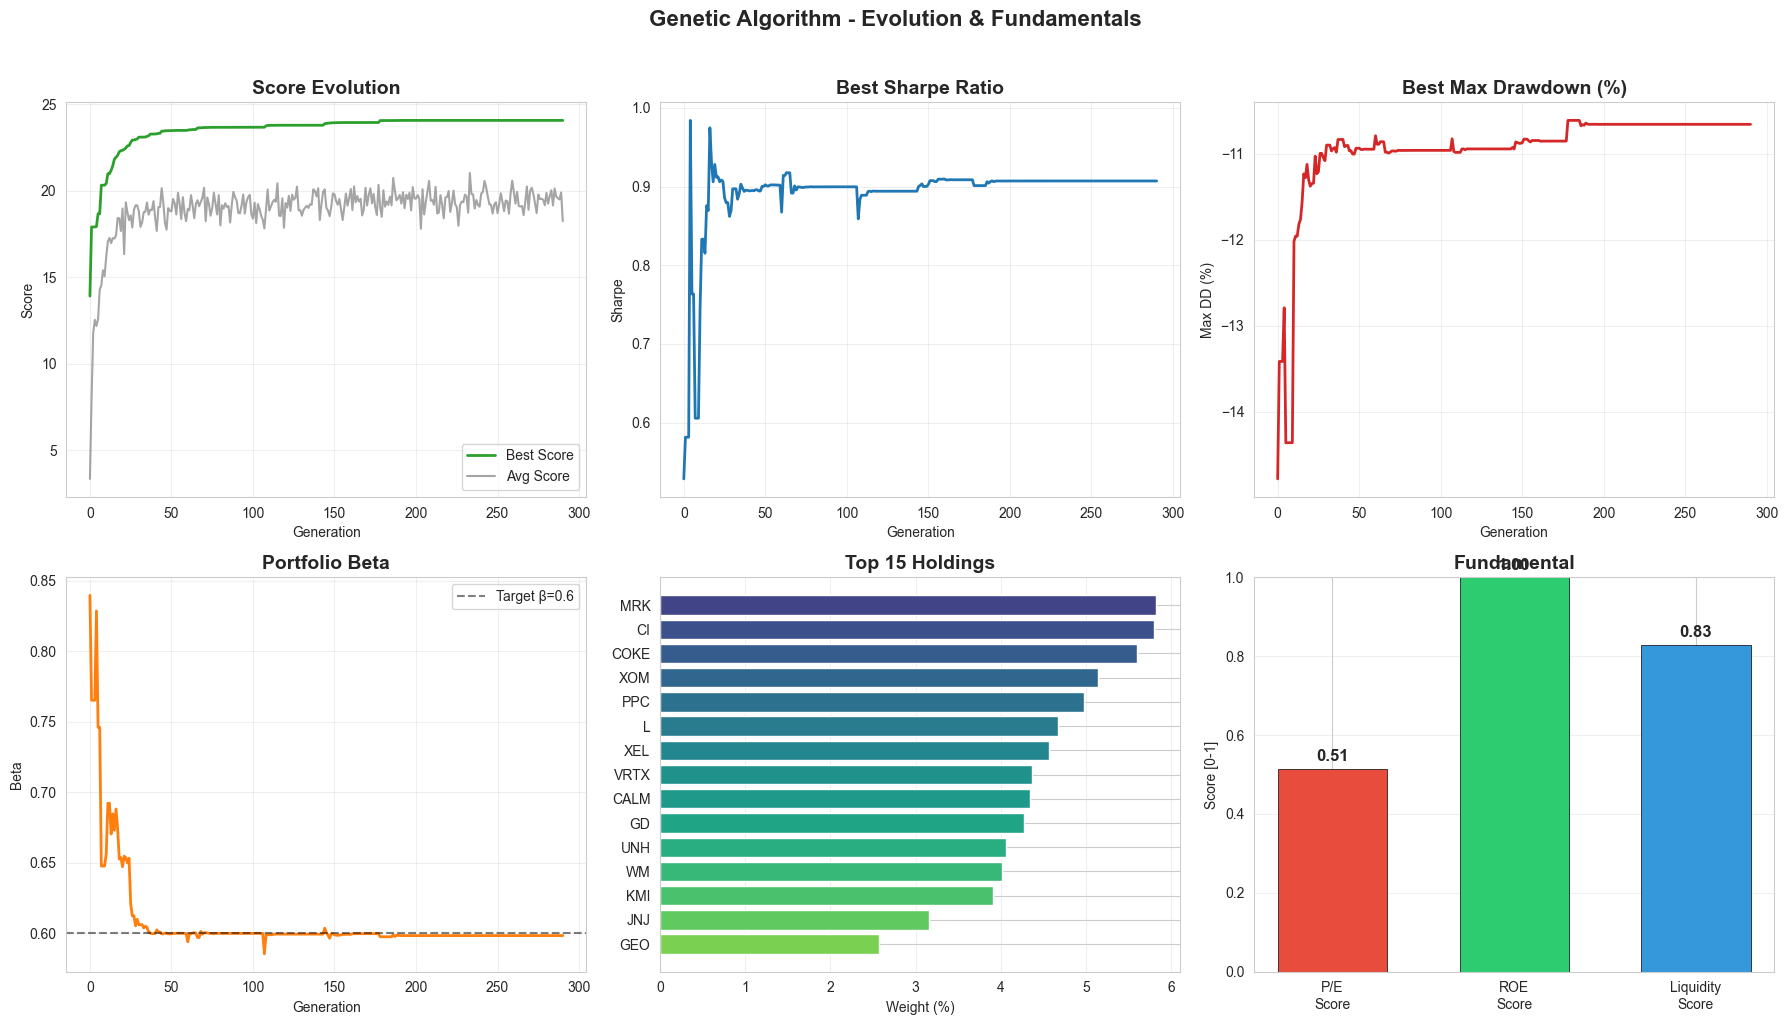

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
ax.plot(history['best_score'], label='Best Score', linewidth=2, color='#2ca02c')
ax.plot(history['avg_score'], label='Avg Score', linewidth=1.5, alpha=0.7, color='#7f7f7f')
ax.set_title('Score Evolution', fontsize=14, fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Score')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(history['best_sharpe'], linewidth=2, color='#1f77b4')
ax.set_title('Best Sharpe Ratio', fontsize=14, fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Sharpe')
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.plot([dd * 100 for dd in history['best_drawdown']], linewidth=2, color='#d62728')
ax.set_title('Best Max Drawdown (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Max DD (%)')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(history['best_beta'], linewidth=2, color='#ff7f0e')
ax.axhline(y=TARGET_BETA, color='black', linestyle='--', alpha=0.5, label=f'Target β={TARGET_BETA}')
ax.set_title('Portfolio Beta', fontsize=14, fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Beta')
ax.legend()
ax.grid(True, alpha=0.3)

# Weight distribution
ax = axes[1, 1]
top_n = 15
top_df = portfolio_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, top_n))
ax.barh(range(top_n), top_df['Weight (%)'], color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_df['Ticker'])
ax.invert_yaxis()
ax.set_xlabel('Weight (%)')
ax.set_title(f'Top {top_n} Holdings', fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

# Fundamental breakdown
ax = axes[1, 2]
labels = ['P/E\nScore', 'ROE\nScore', 'Liquidity\nScore']
values = [best_overall['pe_score'], best_overall['roe_score'], best_overall['liq_score']]
bar_colors = ['#e74c3c', '#2ecc71', '#3498db']
bars = ax.bar(labels, values, color=bar_colors, width=0.6, edgecolor='black', linewidth=0.5)
ax.set_ylim(0, 1)
ax.set_title('Fundamental', fontsize=14, fontweight='bold')
ax.set_ylabel('Score [0-1]')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Genetic Algorithm - Evolution & Fundamentals', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **4. Out-of-Sample Backtest (2024)**
---

This is the critical validation step. The GA has **never seen** 2024 data.
We compare the GA portfolio against the equally-weighted S&P 1500 benchmark.

### **4.1 Performance Chart**

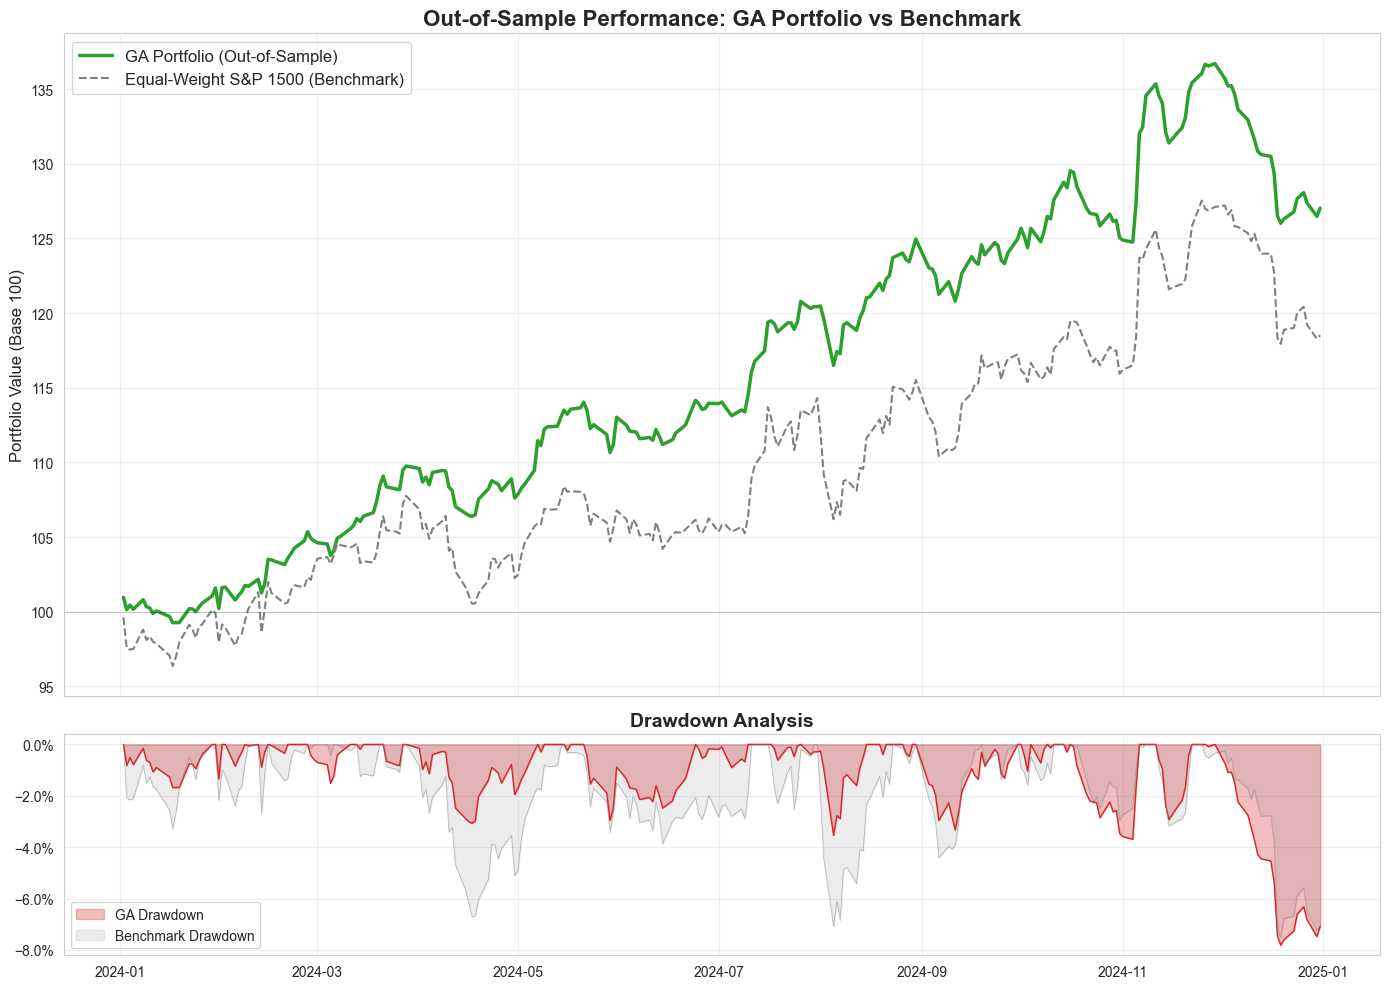

In [11]:
# GA Portfolio (weighted)
available_test = [t for t in final_tickers if t in test_returns.columns]
mask = np.array([t in available_test for t in final_tickers])
test_weights = final_weights[mask]
test_weights = test_weights / test_weights.sum()

ga_daily = (test_returns[available_test] * test_weights).sum(axis=1)

# Benchmark (equally-weighted S&P 1500 universe)
bench_tickers = [t for t in valid_tickers if t in test_returns.columns]
bench_daily = test_returns[bench_tickers].mean(axis=1)

# Cumulative (Base 100)
ga_cumulative = (1 + ga_daily).cumprod() * 100
bench_cumulative = (1 + bench_daily).cumprod() * 100

# Drawdown
def calc_drawdown(cum):
    peak = cum.cummax()
    return (cum - peak) / peak

ga_dd = calc_drawdown(ga_cumulative)
bench_dd = calc_drawdown(bench_cumulative)

# --- PLOT ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(ga_cumulative.index, ga_cumulative,
         label='GA Portfolio (Out-of-Sample)', color='#2ca02c', linewidth=2.5)
ax1.plot(bench_cumulative.index, bench_cumulative,
         label='Equal-Weight S&P 1500 (Benchmark)', color='#7f7f7f', linestyle='--', linewidth=1.5)
ax1.axhline(y=100, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
ax1.set_title('Out-of-Sample Performance: GA Portfolio vs Benchmark',
              fontsize=16, fontweight='bold')
ax1.set_ylabel('Portfolio Value (Base 100)', fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.fill_between(ga_dd.index, ga_dd, 0, color='#d62728', alpha=0.3, label='GA Drawdown')
ax2.plot(ga_dd.index, ga_dd, color='#d62728', linewidth=1)
ax2.fill_between(bench_dd.index, bench_dd, 0, color='gray', alpha=0.15, label='Benchmark Drawdown')
ax2.plot(bench_dd.index, bench_dd, color='gray', linewidth=0.5, alpha=0.5)
ax2.set_title('Drawdown Analysis', fontsize=14, fontweight='bold')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **4.2 Performance Metrics**

In [12]:
def print_metrics(daily_ret, label):
    """Compute and print performance metrics."""
    cum = (1 + daily_ret).cumprod()
    total = cum.iloc[-1] / cum.iloc[0] - 1
    ann_ret = daily_ret.mean() * 252
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = (ann_ret - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0

    down = daily_ret[daily_ret < 0]
    down_vol = down.std() * np.sqrt(252) if len(down) > 0 else ann_vol
    sortino = (ann_ret - RISK_FREE_RATE) / down_vol if down_vol > 0 else 0

    peak = cum.cummax()
    max_dd = ((cum - peak) / peak).min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    win_rate = (daily_ret > 0).mean()

    print(f"  {label}")
    print(f"  Total Return:     {total*100:+.2f}%")
    print(f"  Ann. Return:      {ann_ret*100:+.2f}%")
    print(f"  Ann. Volatility:  {ann_vol*100:.2f}%")
    print(f"  Sharpe Ratio:     {sharpe:.4f}")
    print(f"  Sortino Ratio:    {sortino:.4f}")
    print(f"  Max Drawdown:     {max_dd*100:.2f}%")
    print(f"  Calmar Ratio:     {calmar:.4f}")
    print(f"  Win Rate:         {win_rate*100:.1f}%")

    return {'total': total, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 'sortino': sortino, 'max_dd': max_dd,
            'calmar': calmar, 'win_rate': win_rate}

ga_m = print_metrics(ga_daily, "GA PORTFOLIO (Out-of-Sample)")
bench_m = print_metrics(bench_daily, "BENCHMARK (Equal-Weight S&P 1500)")

  GA PORTFOLIO (Out-of-Sample)
  Total Return:     +25.81%
  Ann. Return:      +24.54%
  Ann. Volatility:  11.08%
  Sharpe Ratio:     1.8542
  Sortino Ratio:    3.0809
  Max Drawdown:     -7.82%
  Calmar Ratio:     3.1389
  Win Rate:         53.6%
  BENCHMARK (Equal-Weight S&P 1500)
  Total Return:     +18.97%
  Ann. Return:      +18.18%
  Ann. Volatility:  15.41%
  Sharpe Ratio:     0.9200
  Sortino Ratio:    1.3719
  Max Drawdown:     -7.52%
  Calmar Ratio:     2.4163
  Win Rate:         53.6%
